In [1]:
%%bash
pip install qiskit qiskit-aer pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 86.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.8 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=e8bd9eacdfa5b7b6da3d7568a8ce9cb5f6bfcbdac88b1595a5743df0cac16f20
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [2]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister, Parameter, ClassicalRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit import transpile
from qiskit_aer import AerSimulator
import pylatexenc
import numpy as np

List of functions:

*   SudokuSolver: main function that solves an n*n Sudoku
*   Grover_search: performs the Grover search algorithm. This is used in SudokuSolver

*   DistinctFour: key helper function which takes a group of four entries in the Sudoku (i.e. row/column/box) and checks whether all the entries are distinct.
*   increment_counter: helper function used to increment the counter registers (in order to keep track of the occurences where the same number appears more than once in the same group of four).

In [3]:
n = 4 #size of the board
d = 2 #number of bits needed to store each entry

def SudokuSolver(input_matrix):
    #input is an n*n Sudoku board, where unclued entries are marked with '0'

    #stores the states of unknown entries in the Sudoku board
    memory_registers = []
    #qubit used to implement phase flips in Grover algorithm
    phase_register = QuantumRegister(1, name="phase")
    #counter for the number of violations of Sudoku in the board
    count_register = QuantumRegister(7, name="count")
    #ancilla used in the process of violation checks (in DistinctFour())
    ancilla_compare = QuantumRegister(1, name="ancilla")

    #each entry of this matrix is either a clue or an index to the
    #corresponding memory register
    #(the entry 'i' corresponds to the (-i-1)-th register)
    mapping_matrix = np.array(input_matrix, dtype=int)
    N = 0 # number of unclued entries
    for y in range(n):
        for x in range(n):
            if input_matrix[y][x] == 0:
                new_reg = QuantumRegister(d, name=f"reg_{x}_{y}")
                memory_registers.append(new_reg)
                N += 1
                mapping_matrix[y][x] = -N
    #enumerating the groups of four that need to be checked in Sudoku
    groups = []
    for i in range(n): groups.append([(j, i) for j in range(n)]) # Rows
    for i in range(n): groups.append([(i, j) for j in range(n)]) # Cols
    for r in range(0, n, 2):
        for c in range(0, n, 2):
            groups.append([(c + i, r + j) for i in range(2) for j in range(2)])

    # 1. Diffuser
    all_memory_qubits = [q for reg in memory_registers for q in reg]
    diff_qc = QuantumCircuit(*memory_registers, phase_register)
    diff_qc.h(all_memory_qubits)
    diff_qc.x(all_memory_qubits)
    diff_qc.x(phase_register[0])
    # Grover_search prepares phase_register in |-> state, so this achieves the
    # phase flip precisely when memory registers are not in the state |00...0>
    diff_qc.mcx(all_memory_qubits, phase_register[0])
    diff_qc.x(all_memory_qubits)
    diff_qc.h(all_memory_qubits)
    S = diff_qc.to_gate(label="S")

    # 2. Marker
    compute_qc = QuantumCircuit(*memory_registers, count_register, ancilla_compare)
    #check for violations of Sudoku rules
    for group in groups:
        DistinctFour(group, compute_qc, memory_registers, ancilla_compare[0], count_register, mapping_matrix)

    marker_qc = QuantumCircuit(*memory_registers, phase_register, count_register, ancilla_compare)
    compute_qc_qubits = [q for reg in memory_registers for q in reg] + list(count_register) + list(ancilla_compare)

    marker_qc.append(compute_qc.to_gate(label="Comp"), compute_qc_qubits)
    #flips phase if count_register is |00...0> (i.e. the number of violations to the rule of Sudoku is 0)
    marker_qc.x(count_register)
    marker_qc.mcx(count_register, phase_register[0])
    marker_qc.x(count_register)
    marker_qc.append(compute_qc.inverse().to_gate(label="Uncomp"), compute_qc_qubits)
    U = marker_qc.to_gate(label="U")

    rep = int(np.rint(np.pi / 4 * np.sqrt(2**(d*N))))
    qc = QuantumCircuit(*memory_registers, phase_register, count_register, ancilla_compare)
    Grover_search(qc, memory_registers, phase_register, count_register, ancilla_compare, S, U, rep)

    return qc, mapping_matrix, marker_qc, diff_qc

In [4]:
def Grover_search(circuit, memory_registers, phase_register, count_register, ancilla_compare, S, U, rep):
  all_memory_qubits = [q for reg in memory_registers for q in reg]
  circuit.h(all_memory_qubits) # state preparation for memory registers
  circuit.x(phase_register) # phase qubit must be in state (|0>-|1>)/sqrt{2}
  circuit.h(phase_register)

  qubits_for_U = all_memory_qubits + list(phase_register) + list(count_register) + list(ancilla_compare)
  qubits_for_S = all_memory_qubits + list(phase_register)

  for _ in range(rep):
    circuit.barrier()
    circuit.compose(U, qubits=qubits_for_U, inplace=True)
    circuit.compose(S, qubits=qubits_for_S, inplace=True)

In [5]:
def DistinctFour(group, circuit, memory_registers, ancilla_bit, count_register, matrix):
    # Compares all 6 pairs in a group of 4.
    # If a pair is equal, it sets ancilla_bit to 1, increments counter, then resets ancilla_bit.
    for i in range(len(group)):
        for j in range(i + 1, len(group)):
            x_0, y_0 = group[i]
            x_1, y_1 = group[j]
            p = matrix[y_0][x_0]
            q = matrix[y_1][x_1]

            #both are clued
            if p > 0 and q > 0: continue

            #one clue, one unknown
            if p > 0 or q > 0:

                clue_val = (p - 1) % 4 if p > 0 else (q - 1) % 4
                unknown_idx = -q - 1 if p > 0 else -p - 1
                target_reg = memory_registers[unknown_idx]

                bit0, bit1 = clue_val % 2, clue_val // 2
                if bit0 == 0: circuit.x(target_reg[0])
                if bit1 == 0: circuit.x(target_reg[1])

                circuit.mcx(target_reg, ancilla_bit)
                increment_counter(circuit, ancilla_bit, count_register)
                circuit.mcx(target_reg, ancilla_bit)

                if bit1 == 0: circuit.x(target_reg[1])
                if bit0 == 0: circuit.x(target_reg[0])

            else:
                #both unknown
                reg_p = memory_registers[-p-1]
                reg_q = memory_registers[-q-1]
                circuit.cx(reg_p[0], reg_q[0])
                circuit.cx(reg_p[1], reg_q[1])
                circuit.x(reg_q[0])
                circuit.x(reg_q[1])

                circuit.mcx(reg_q, ancilla_bit)
                increment_counter(circuit, ancilla_bit, count_register)
                circuit.mcx(reg_q, ancilla_bit)

                circuit.x(reg_q[1])
                circuit.x(reg_q[0])
                circuit.cx(reg_p[1], reg_q[1])
                circuit.cx(reg_p[0], reg_q[0])

In [6]:
def increment_counter(circuit, flag_qubit, counter_register):
  # increment counter_register if flag_qubit is |1>
  controls = [flag_qubit]
  for i in range(len(counter_register) - 1, 0, -1):
    circuit.mcx(controls + list(counter_register[0:i]), counter_register[i])
  circuit.cx(flag_qubit, counter_register[0])

We test this on the following Sudoku. We take measurements 5 times and pick the most frequent output.

In [7]:
test_Sudoku_A = [
  [0, 1, 0, 3],
  [3, 4, 0, 2],
  [4, 3, 2, 1],
  [1, 2, 3, 4]
]

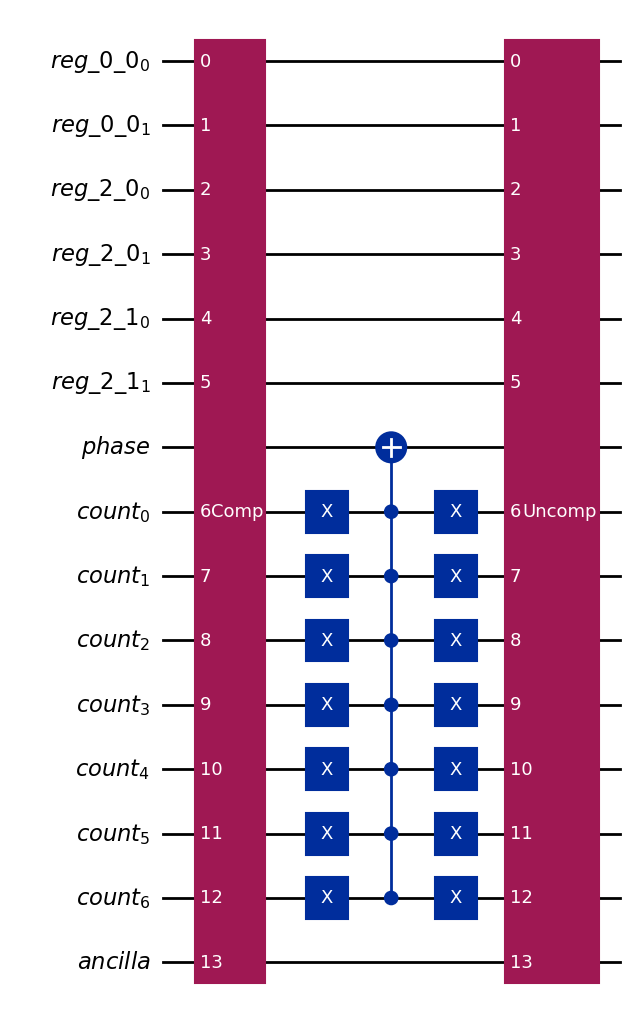

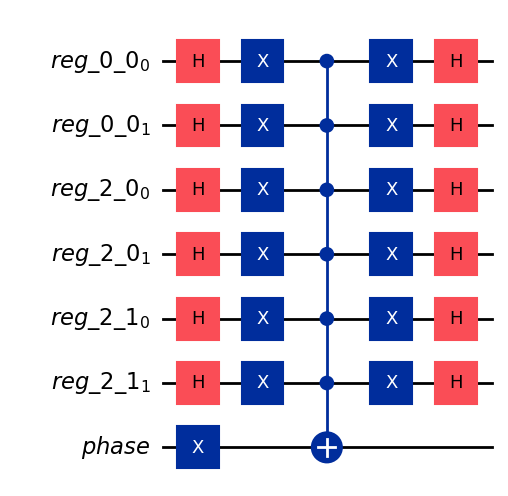

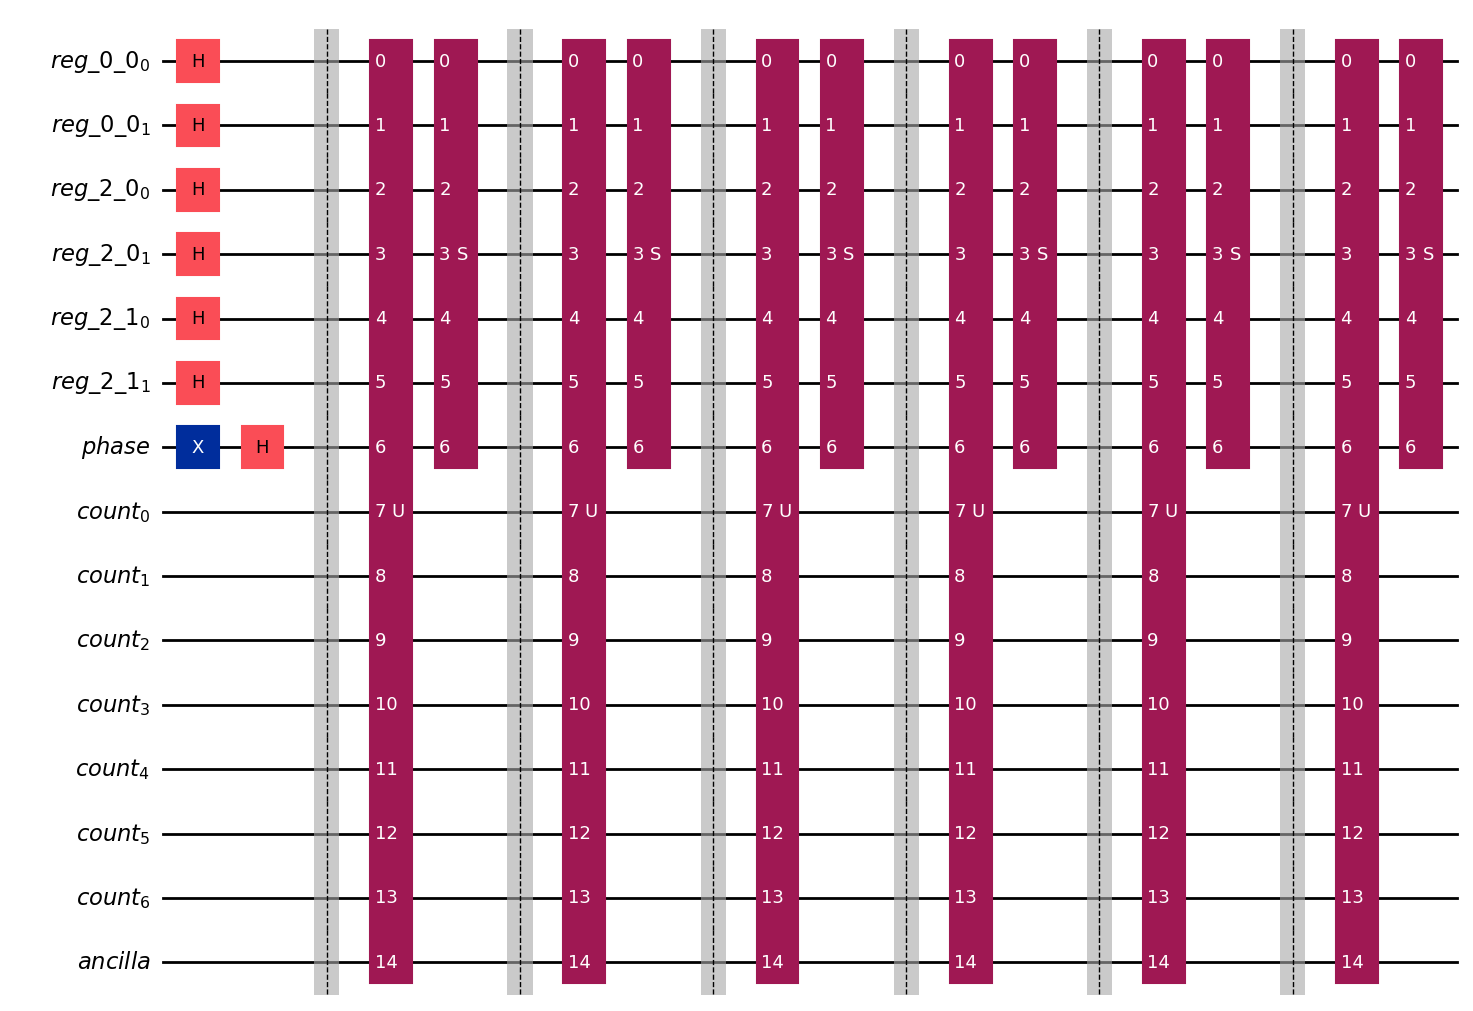

Solved Sudoku Matrix:
[[2 1 4 3]
 [3 4 1 2]
 [4 3 2 1]
 [1 2 3 4]]


In [8]:
from qiskit import ClassicalRegister, transpile
from qiskit_aer import AerSimulator
import numpy as np
from IPython.display import display

#call SudokuSolver
qc, mapping_matrix, full_oracle, diff_qc = SudokuSolver(test_Sudoku_A)

#display the circuit diagrams
display(full_oracle.draw(output="mpl"))
display(diff_qc.draw(output="mpl"))
display(qc.draw(output="mpl"))

#add classical bits to measure
memory_regs = [reg for reg in qc.qregs if reg.name.startswith("reg_")]
for i, reg in enumerate(memory_regs):
    cr = ClassicalRegister(2, name=f"m{i}")
    qc.add_register(cr)
    qc.measure(reg, cr)

#simulation
backend = AerSimulator(method='statevector')
tqc = transpile(qc, backend, optimization_level=0)
job = backend.run(tqc, shots=5) #measure 5 times
result = job.result()
counts = result.get_counts()
#get the best result
best_guess = max(counts, key=counts.get)
bit_parts = best_guess.split(" ")[::-1]
#recover the Sudoku board from measurements
answer_matrix = np.zeros((4,4), dtype=int)
for y in range(4):
    for x in range(4):
        val = mapping_matrix[y][x]
        if val > 0:
            answer_matrix[y][x] = val
        else:
            reg_idx = -val - 1
            bits = bit_parts[reg_idx]
            # Map 0-3 back to 1-4
            answer_matrix[y][x] = int(bits, 2) + 1

print("Solved Sudoku Matrix:")
print(answer_matrix)

We repeat this on the following Sudoku. We don't display the circuits this time since they are quite large.

In [9]:
test_Sudoku_B = [
  [0, 1, 0, 3],
  [3, 4, 0, 2],
  [4, 3, 2, 0],
  [1, 0, 3, 4]
]

In [10]:
from qiskit import ClassicalRegister, transpile
from qiskit_aer import AerSimulator
import numpy as np
from IPython.display import display

#call SudokuSolver
qc, mapping_matrix, full_oracle, diff_qc = SudokuSolver(test_Sudoku_B)

#add classical bits to measure
memory_regs = [reg for reg in qc.qregs if reg.name.startswith("reg_")]
for i, reg in enumerate(memory_regs):
    cr = ClassicalRegister(2, name=f"m{i}")
    qc.add_register(cr)
    qc.measure(reg, cr)

#simulation
backend = AerSimulator(method='statevector')
tqc = transpile(qc, backend, optimization_level=0)
job = backend.run(tqc, shots=5) #measure 5 times
result = job.result()
counts = result.get_counts()
#get the best result
best_guess = max(counts, key=counts.get)
bit_parts = best_guess.split(" ")[::-1]
#recover the Sudoku board from measurements
answer_matrix = np.zeros((4,4), dtype=int)
for y in range(4):
    for x in range(4):
        val = mapping_matrix[y][x]
        if val > 0:
            answer_matrix[y][x] = val
        else:
            reg_idx = -val - 1
            bits = bit_parts[reg_idx]
            # Map 0-3 back to 1-4
            answer_matrix[y][x] = int(bits, 2) + 1

print("Solved Sudoku Matrix:")
print(answer_matrix)

Solved Sudoku Matrix:
[[2 1 4 3]
 [3 4 1 2]
 [4 3 2 1]
 [1 2 3 4]]
